## Task 1: Data Loading and Preprocessing
### Step 1: Import Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

## Explanation

- tensorflow → Deep Learning framework.
- fashion_mnist → Dataset containing fashion images.
- matplotlib → Used for visualization.
- numpy → Numerical operations.

### Step 2: Load Fashion-MNIST Dataset

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


## Explanation

Fashion-MNIST contains:

- 60,000 training images
- 10,000 testing images
- Image size = 28 × 28 pixels
- Grayscale images

### Step 3: Normalize Images

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Explanation

Pixel values originally:
```
0 - 255
```
After normalization:
```
0 - 1
```
Benefits:

- Faster training
- Better convergence
- Stable gradients


### Step 4: Reshape for CNN

CNN expects:
```
(height, width, channels)
```
For grayscale images:
```
(28,28,1)
```


In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### Step 5: Display Sample Images

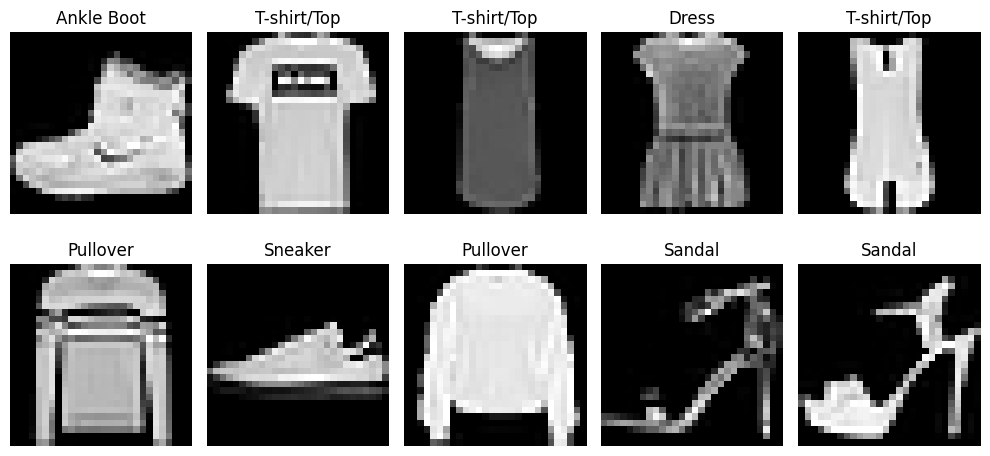

In [ ]:
class_names = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Explanation

Displays 10 images with labels such as:

- Shirt
- Trouser
- Bag
- Sneaker

Take screenshot for report.

## Task 2: Design / Build CNN Model

CNN Architecture

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

## Build Model

In [ ]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))

# First Pooling Layer
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Second Pooling Layer
model.add(MaxPooling2D((2,2)))

# Dropout Layer
model.add(Dropout(0.25))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    10,
    activation='softmax'
))

## Explanation of Layers

Conv2D
```
Conv2D(32,(3,3))
```
Learns image features:

- edges
- patterns
- textures

32 filters are applied.

MaxPooling
```
MaxPooling2D((2,2))
```

Reduces image size.

Example:
```
28x28 → 14x14
```

Benefits:

- Faster computation
- Less overfitting

Dropout
```
Dropout(0.25)
```

Randomly disables neurons during training.

Benefits:

- Prevents overfitting
- Improves generalization

Flatten
```
Flatten()
```
Converts:
```
2D feature maps
```

into
```
1D vector
```
for Dense layers.

Dense
```
Dense(128)
```

Learns high-level patterns.

Softmax Output

```
Dense(10, activation='softmax')
```

Predicts probabilities for:
```
10 fashion classes
```


## Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Explanation

Optimizer:
```
adam
```
updates weights efficiently.

Loss:
```
sparse_categorical_crossentropy
```
used for multi-class classification.

Metric:
```
accuracy
```
measures correct predictions.

## Model Summary

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile and Train Model

### Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6959 - loss: 1.1887 - val_accuracy: 0.8160 - val_loss: 0.4820
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7947 - loss: 0.5562 - val_accuracy: 0.8480 - val_loss: 0.4104
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8248 - loss: 0.4803 - val_accuracy: 0.8597 - val_loss: 0.3646
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8356 - loss: 0.4386 - val_accuracy: 0.8730 - val_loss: 0.3423
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8480 - loss: 0.4066 - val_accuracy: 0.8751 - val_loss: 0.3308
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8539 - loss: 0.3913 - val_accuracy: 0.8815 - val_loss: 0.3205
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8609 - loss: 0.3748 - val_accuracy: 0.8850 - val_loss: 0.3056
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8655 - loss: 0.3593 - val_accuracy: 0

## Explanation

- 80% training
- 20% validation

Epochs:
```
15
```
means dataset is processed 15 times.

Batch size:
```
64
```

processes 64 images at a time.

## Task 4: Model Evaluation
### Evaluate on Test Dataset

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8883 - loss: 0.3087
Test Loss: 0.30873236060142517
Test Accuracy: 0.8883000016212463


Meaning:
```
88% images classified correctly
```


### Generate Predictions

In [ ]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Confusion Matrix

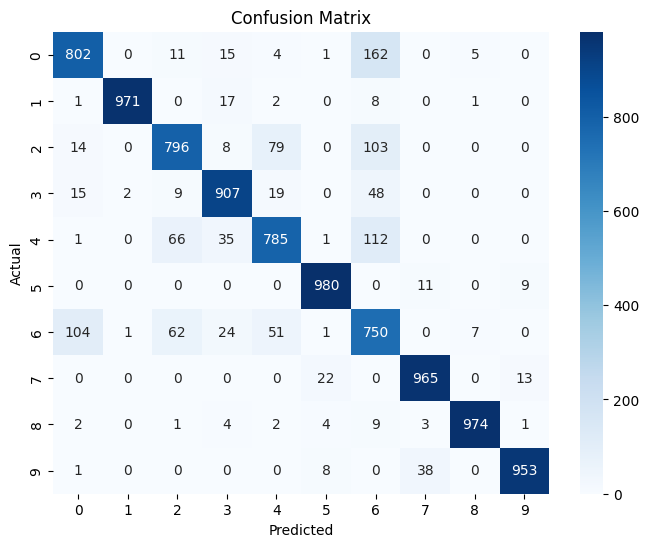

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Explanation

Shows:

- correct classifications
- Misclassifications

## Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/Top       0.85      0.80      0.83      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.84      0.80      0.82      1000
       Dress       0.90      0.91      0.90      1000
        Coat       0.83      0.79      0.81      1000
      Sandal       0.96      0.98      0.97      1000
       Shirt       0.63      0.75      0.68      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle Boot       0.98      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### Metrics

Precision
```
Correct Positive Predictions
----------------------------
Total Positive Predictions
```

Recall
```
Correct Positive Predictions
----------------------------
Actual Positive Cases
```

F1-score

Balance between Precision and Recall.

## Task 5: Visualization and Analysis
### Plot Accuracy Curve

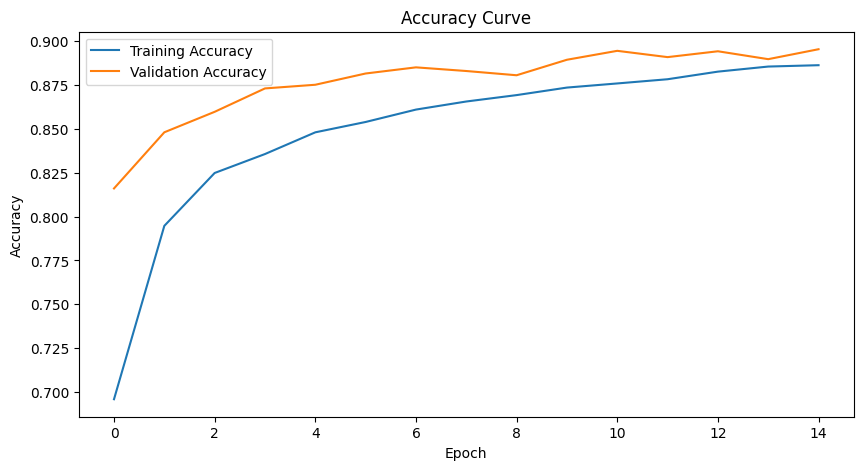

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Interpretation

If curves rise together:

Model learning correctly

## Plot Loss Curve

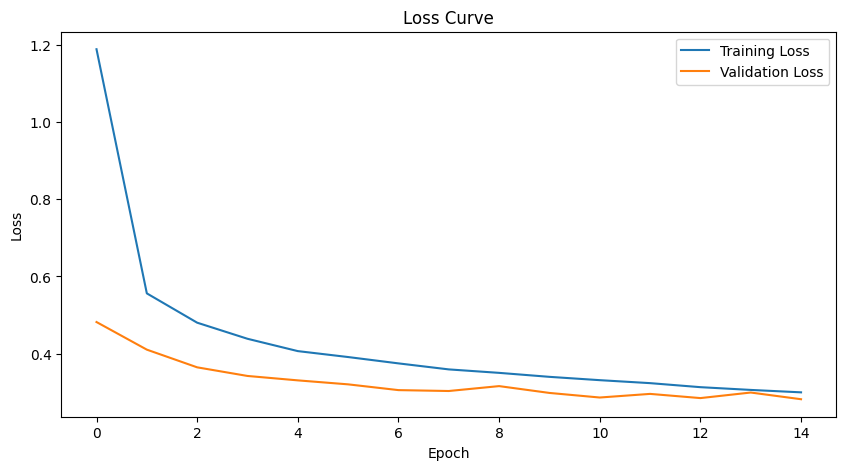

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Interpretation

Good model:

```
Loss decreases over epochs
```

## Display Predictions

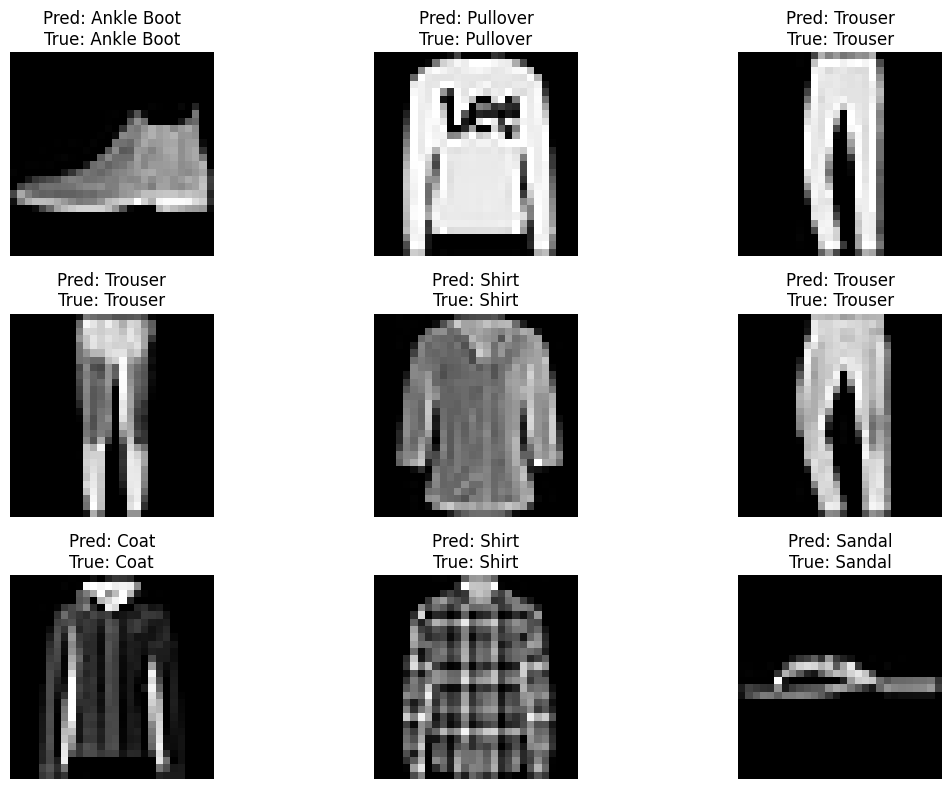

In [ ]:
plt.figure(figsize=(12,8))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Pred: {class_names[y_pred[i]]}\nTrue: {class_names[y_test[i]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

### Explanation

Shows:

- Test image
- Predicted label
- Actual label

Useful for visual verification.

## Expected Report Conclusion

A Convolutional Neural Network (CNN) was developed using TensorFlow/Keras for Fashion-MNIST image classification. The dataset was normalized and reshaped before training. The CNN consisted of two convolutional layers, max-pooling layers, dropout regularization, and fully connected dense layers. After training for 15 epochs, the model achieved approximately 85–89% test accuracy. Evaluation using a confusion matrix and classification report showed strong performance across most fashion categories. Training and validation curves indicated effective learning with minimal overfitting.